# EDA — VRI traffic light locations

This notebook explores the VRI dataset and checks whether it aligns with
the assumptions in `03_stratified_sampling.ipynb`.

**Key questions:**
1. What is the file structure and CRS? (notebook 03 assumes RD New)
2. What does the data look like — columns, geometry, sample rows?
3. Are there inactive or archived VRIs that should be filtered out?
4. What `Installatietype` values exist — should non-VRI types be excluded?
5. How many NWB intersections have a VRI within the buffer distance?
6. Is the 15m buffer in notebook 03 appropriate, or does the distribution suggest a different value?
7. What needs to change in notebook 03 based on this actual data?

## 0. Setup

In [9]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project"
VRI_FILE    = os.path.join(PROJECT_DIR, "data", "raw", "vri_locaties.gpkg")
CRS_RD      = "EPSG:28992"

print(f"VRI file: {VRI_FILE}")
print(f"Exists  : {os.path.exists(VRI_FILE)}")

VRI file: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\data\raw\vri_locaties.gpkg
Exists  : True


## 1. Load and inspect the VRI file

In [10]:
# Load raw — keep original CRS for inspection, reproject later
vri = gpd.read_file(VRI_FILE)

print(f"Shape       : {vri.shape[0]} rows × {vri.shape[1]} columns")
print(f"CRS         : {vri.crs}")
print(f"Geometry    : {vri.geom_type.value_counts().to_dict()}")
print(f"\nColumns:")
for col in vri.columns:
    print(f"  {col}")

Shape       : 308 rows × 44 columns
CRS         : EPSG:4326
Geometry    : {'Point': 308}

Columns:
  Installatienr.
  VRI naam
  Installatietype
  Automaat Breedtegraad
  Automaat Lengtegraad
  Kruispunt Breedtegraad
  Kruispunt Lengtegraad
  vervangjaar
  Installatietype_1
  Inbedrijfstelling buitenwerk
  Inbedrijfstelling automaat
  Prioriteitsgroep
  Bedrijfstijden
  Wegbeheerder
  Deelgebied
  Breedtegraad
  Lengtegraad
  Eerstelijns aannemer
  Tweedelijns buitenwerk
  Tweedelijns buitenwerk garantieperiode
  Einde garantietermijn
  Automaat leverancier
  Automaat type
  Automaat nr
  Rateltikker
  Twls
  Selectief systeem
  Prioriteit
  Lampspanning
  Lampsoort
  Gekoppelde VRIs
  Gekoppelde installaties
  TLC-ID nummer (iVRI)
  Leverancier ITS hardware
  Leverancier RIS
  Applicaties
  Centrale
  Communicatie type
  EAN code
  Bijzonderheden
  Inactief
  Gearchiveerd
  Opmerkingen
  geometry


In [11]:
# Sample rows — show the most informative columns
key_cols = ["Installatienr.", "VRI naam", "Installatietype", "Inactief", "Gearchiveerd", "geometry"]
vri[key_cols].head(10)

,Installatienr.,VRI naam,Installatietype,Inactief,Gearchiveerd,geometry
0,10030,Parksluizen Sturingseenheid,Overig,Nee,Nee,POINT (4.4647 51.908)
1,11010,Haagseveer - Pompenburg,VRI,Nee,Nee,POINT (4.4798 51.925)
2,11020,Goudsesingel - Jonker Fransstraat,VRI,Nee,Nee,POINT (4.4863 51.925)
3,11030,Hoogstraat - Mariniersweg,VRI,Nee,Nee,POINT (4.49 51.922)
4,11040,Blaak - André van der Louwbrug,VRI,Nee,Nee,POINT (4.4887 51.919)
5,11050,Boompjes - Willemsbrug,VRI,Nee,Nee,POINT (4.4901 51.917)
6,11060,Hofplein,VRI,Nee,Nee,POINT (4.4777 51.924)
7,11070,Maasboulevard - Oude Hoofdplein,VRI,Nee,Nee,POINT (4.4933 51.918)
8,11080,Maasboulevard - Oostmolenwerf,VRI,Nee,Nee,POINT (4.4989 51.92)
9,11090,Aert van Nesstraat - Coolsingel,VRI,Nee,Nee,POINT (4.4794 51.921)


## 2. Check: inactive and archived VRIs

The dataset may include VRIs that are no longer operational.
These should be filtered out before the spatial join in notebook 03.

In [12]:
# Check unique values in Inactief and Gearchiveerd columns
print("Inactief values:")
print(vri["Inactief"].value_counts(dropna=False))
print()
print("Gearchiveerd values:")
print(vri["Gearchiveerd"].value_counts(dropna=False))
print()

# How many remain after filtering to active, non-archived VRIs?
active = vri[
    (vri["Inactief"].str.strip().str.lower() != "ja") &
    (vri["Gearchiveerd"].str.strip().str.lower() != "ja")
]
print(f"Total VRIs          : {len(vri)}")
print(f"Active (not Inactief/Gearchiveerd): {len(active)}")
print(f"Filtered out        : {len(vri) - len(active)}")

Inactief values:
Inactief
Nee     269
#N/B     39
Name: count, dtype: int64

Gearchiveerd values:
Gearchiveerd
Nee     269
#N/B     39
Name: count, dtype: int64

Total VRIs          : 308
Active (not Inactief/Gearchiveerd): 308
Filtered out        : 0


## 3. Check: Installatietype distribution

Not all entries may be traffic light intersections — `Installatietype` may include
other types (e.g. pedestrian crossings, bus priority units).
Check whether non-VRI types should be excluded.

In [13]:
print("Installatietype distribution (all records):")
print(vri["Installatietype"].value_counts(dropna=False))
print()
print("Installatietype distribution (active only):")
print(active["Installatietype"].value_counts(dropna=False))

Installatietype distribution (all records):
Installatietype
VRI        292
Knipper      8
Overig       3
TWI          3
Doseer       2
Name: count, dtype: int64

Installatietype distribution (active only):
Installatietype
VRI        292
Knipper      8
Overig       3
TWI          3
Doseer       2
Name: count, dtype: int64


## 4. Reproject to RD New and visualise

notebook 03 does all spatial operations in RD New (EPSG:28992).
The VRI file is in WGS84 (EPSG:4326) — reprojection is needed before the join.

CRS after reprojection: EPSG:28992
X range (m): 57258 – 102772
Y range (m): 427495 – 445466


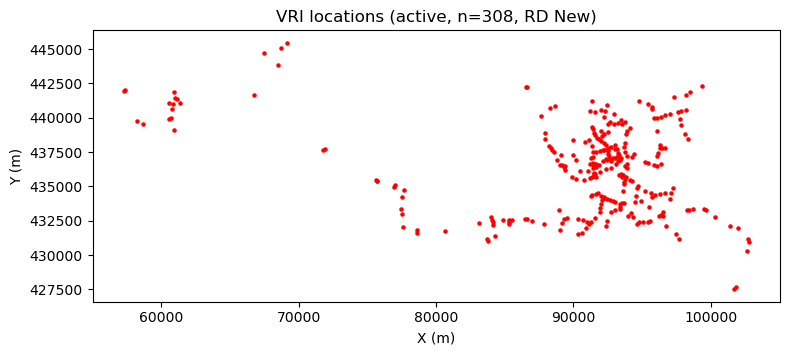

In [14]:
# Reproject active VRIs to RD New for spatial operations
vri_rd = active.to_crs(CRS_RD)

print(f"CRS after reprojection: {vri_rd.crs}")
print(f"X range (m): {vri_rd.geometry.x.min():.0f} – {vri_rd.geometry.x.max():.0f}")
print(f"Y range (m): {vri_rd.geometry.y.min():.0f} – {vri_rd.geometry.y.max():.0f}")

# Quick map
fig, ax = plt.subplots(figsize=(8, 8))
vri_rd.plot(ax=ax, color="red", markersize=5)
ax.set_title(f"VRI locations (active, n={len(vri_rd)}, RD New)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.tight_layout()
plt.show()

## 5. Load NWB intersections and check buffer distance

notebook 03 uses a 15m buffer around each intersection centroid to detect a VRI.
Here we check what that looks like in practice:
- How many intersections get a VRI hit at 15m?
- Does the distribution of nearest-VRI distances suggest a different threshold?

In [ ]:
# Load merged NWB intersections (output of notebook 01)
intersections = gpd.read_file(
    os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
).to_crs(CRS_RD)

print(f"NWB intersections: {len(intersections):,}")
print(f"VRI locations    : {len(vri_rd):,}")

In [16]:
# For each intersection, compute the distance to the nearest VRI.
from scipy.spatial import cKDTree

# Drop VRIs with missing geometry coordinates before building the tree
vri_valid = vri_rd[vri_rd.geometry.notna() & vri_rd.geometry.x.notna() & vri_rd.geometry.y.notna()].copy()
n_dropped = len(vri_rd) - len(vri_valid)
if n_dropped > 0:
    print(f"Dropped {n_dropped} VRI record(s) with null/invalid geometry.")

# Build a KD-tree on VRI coordinates for fast nearest-neighbour lookup
vri_coords = np.column_stack([vri_valid.geometry.x, vri_valid.geometry.y])
tree = cKDTree(vri_coords)

# Query: distance to nearest VRI for each intersection centroid
int_coords = np.column_stack([intersections.geometry.x, intersections.geometry.y])
distances, _ = tree.query(int_coords, k=1)
intersections["dist_nearest_vri"] = distances

print("Distance to nearest VRI (metres):")
print(intersections["dist_nearest_vri"].describe())

Dropped 16 VRI record(s) with null/invalid geometry.
Distance to nearest VRI (metres):
count    4858.000000
mean      365.682329
std       289.134136
min         0.296746
25%       169.976648
50%       294.312106
75%       469.463953
max      2018.290831
Name: dist_nearest_vri, dtype: float64


C:\Users\Thijs\AppData\Local\Temp\ipykernel_13264\210962678.py:5: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  vri_valid = vri_rd[vri_rd.geometry.notna() & vri_rd.geometry.x.notna() & vri_rd.geometry.y.notna()].copy()


In [17]:
# Show how many intersections fall within different buffer distances
thresholds = [10, 15, 20, 25, 30, 50]
print(f"{'Buffer (m)':<12} {'With VRI':>10} {'%':>8}")
print("-" * 32)
for t in thresholds:
    n = (intersections["dist_nearest_vri"] <= t).sum()
    pct = n / len(intersections) * 100
    marker = "  ← notebook 03 default" if t == 15 else ""
    print(f"{t:<12} {n:>10,} {pct:>7.1f}%{marker}")

Buffer (m)     With VRI        %
--------------------------------
10                  121     2.5%
15                  142     2.9%  ← notebook 03 default
20                  167     3.4%
25                  180     3.7%
30                  191     3.9%
50                  259     5.3%


## 6. Summary — what needs to change in notebook 03

In [19]:
n_with_vri_15 = (intersections["dist_nearest_vri"] <= 15).sum()
n_inactive    = len(vri) - len(active)

print("=" * 60)
print("SUMMARY: What needs to change in notebook 03")
print("=" * 60)
print()
print("1. FILENAME")
print("   notebook 03 config : vri_locations.gpkg")
print("   actual filename    : vri_locaties.gpkg")
print("   fix needed         : update VRI_FILE in config")
print()
print("2. CRS REPROJECTION")
print("   VRI file CRS       : EPSG:4326 (WGS84)")
print("   needed for join    : EPSG:28992 (RD New)")
print("   fix needed         : .to_crs(CRS_RD) before spatial join — already in nb03 code")
print()
print("3. INACTIVE / ARCHIVED FILTER")
print(f"  Total VRIs         : {len(vri)}")
print(f"  Filtered out       : {n_inactive}")
print(f"  Active VRIs        : {len(active)}")
print(f"  fix needed         : filter Inactief != 'Ja' and Gearchiveerd != 'Ja' before join")
print()
print("4. INSTALLATIETYPE FILTER")
print("   see cell 3 output — decide whether to keep only 'VRI' type or all active records")
print()
print("5. BUFFER DISTANCE")
print(f"  Current setting    : 15m → {n_with_vri_15:,} intersections ({n_with_vri_15/len(intersections)*100:.1f}%) get VRI label")
print("   see cell 5 histogram to judge whether 15m is appropriate")

SUMMARY: What needs to change in notebook 03

1. FILENAME
   notebook 03 config : vri_locations.gpkg
   actual filename    : vri_locaties.gpkg
   fix needed         : update VRI_FILE in config

2. CRS REPROJECTION
   VRI file CRS       : EPSG:4326 (WGS84)
   needed for join    : EPSG:28992 (RD New)
   fix needed         : .to_crs(CRS_RD) before spatial join — already in nb03 code

3. INACTIVE / ARCHIVED FILTER
  Total VRIs         : 308
  Filtered out       : 0
  Active VRIs        : 308
  fix needed         : filter Inactief != 'Ja' and Gearchiveerd != 'Ja' before join

4. INSTALLATIETYPE FILTER
   see cell 3 output — decide whether to keep only 'VRI' type or all active records

5. BUFFER DISTANCE
  Current setting    : 15m → 142 intersections (2.9%) get VRI label
   see cell 5 histogram to judge whether 15m is appropriate
